# Teoría de Circuitos II

# Tarea Semanal N°2

Autor: Zenobi, Matías Sebastián

![image.png](image.png)

---

## Aproximación de máxima planicidad caso Butterworth de orden 6

$$
|T(j\omega)|^2=\frac1{1+\omega^{2n}}\\
|T(j\omega)|^2\big|_{\omega=s/j}=|T(s)|^2=T(s)\cdot T(-s)=\frac1{1+(\frac sj)^{2n}}=\frac1{1+(-1)^n\cdot s^{2n}}
$$

Como nos piden **orden 6**, $n=6$

$$
|T_{\text{LPF}}(s)|^2=T(s)\cdot T(-s)=\frac1{1+s^{12}}
$$

Ahora quiero conocer la ubicación de los **polos** de esta función.

$$
\begin{align*}
1+s^{12}&=0\\
s^{12}&=-1\\
s^{12}&=e^{j(\pi+2k\pi)}\\
s&=e^{j(\frac1{12}\pi+\frac16k\pi)},k=0,1,2,...,n-1\ (=5)
\end{align*}
$$

![image.png](image%201.png)

Tomo los polos del semiplano **izquierdo** como aquellos que corresponden a  $T(s)$, ya que quiero que mi filtro sea **estable**. Por ende, los polos del semiplano derecho que están *“espejados”* corresponden a  $T(-s)$. 

Los polos están de a **pares complejos conjugados**, tomo el ángulo de uno de cada par (los del cuadrante superior). Estos son (de menor a mayor $Q$):

$$
\frac{11}{12}\pi,\ \frac9{12}\pi=\frac34\pi,\ \frac7{12}\pi
$$

Entonces queda finalmente:

$$
\begin{align*}
T_{\text{LPF}}(s)&=\frac1{[s^2-2\cos(\frac{11}{12}\pi)s+1][s^2-2\cos(\frac34\pi)s+1][s^2-2\cos(\frac7{12}\pi)s+1]}\\
T_{\text{LPF}}(s)&=\frac1{(s^2+1.9318s+1)(s^2+\sqrt2s+1)(s^2+0.5176s+1)}
\end{align*}
$$

A partir de las siguientes observaciones hago **gráficos cualitativos** de la transferencia:

**Diagrama de polos y ceros:** Son los polos del semiplano izquierdo elegidos de la aproximación de máxima planicidad.

**Gráfico de módulo:** Asíntota con pendiente $n\times-20\text{dB/déc.}=-120\text{dB/déc.}$ en $\omega_0=1$, ubicación de los polos.

**Gráfico de fase:** Fase en $\omega_0=1$ es $n\times-45°=-270°$, fase asintótica en el infinito es de
$n\times-180°=-540°$.

![image.png](image%202.png)

---
## Verificación con SymPy

<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\o'
<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Matías Zenobi\AppData\Local\Temp\ipykernel_14884\2985893143.py:45: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Eje Real ($\sigma$)')
C:\Users\Matías Zenobi\AppData\Local\Temp\ipykernel_14884\2985893143.py:46: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('Eje Imaginario ($j\omega$)')


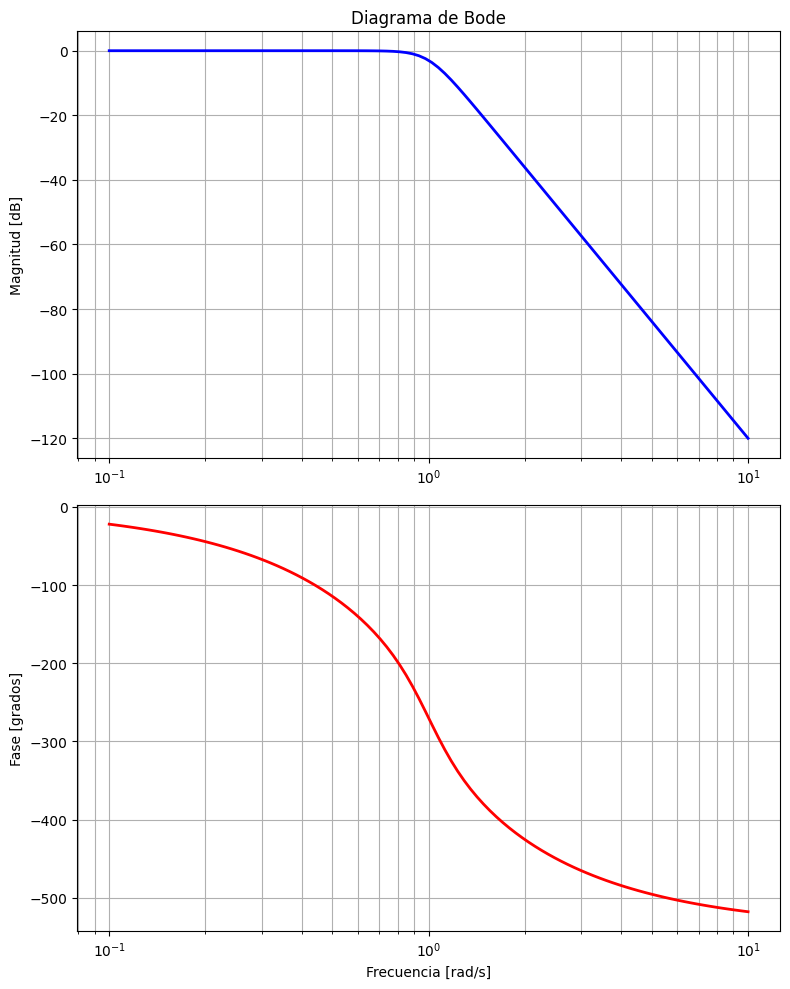

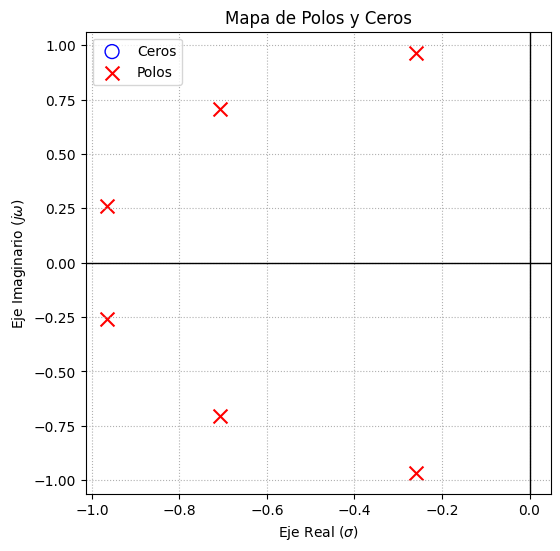

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Función Transferencia

num = [1]
poly1 = [1, 1.9318, 1]
poly2 = [1, np.sqrt(2), 1]
poly3 = [1, 0.5176, 1]
den = np.polymul(np.polymul(poly1, poly2), poly3)

sys = signal.TransferFunction(num, den)

# 2. Gráfico de Bode (Módulo y Fase)
w, mag, phase = signal.bode(sys)

fig, ax1 = plt.subplots(2, 1, figsize=(8, 10))

# Módulo
ax1[0].semilogx(w, mag, color='blue', lw=2)
ax1[0].set_title('Diagrama de Bode')
ax1[0].set_ylabel('Magnitud [dB]')
ax1[0].grid(True, which="both", ls="-")

# Fase
ax1[1].semilogx(w, phase, color='red', lw=2)
ax1[1].set_ylabel('Fase [grados]')
ax1[1].set_xlabel('Frecuencia [rad/s]')
ax1[1].grid(True, which="both", ls="-")

plt.tight_layout()
plt.show()

# 3. Diagrama de Polos y Ceros
zeros = sys.zeros
poles = sys.poles

plt.figure(figsize=(6, 6))
plt.scatter(np.real(zeros), np.imag(zeros), s=100, marker='o', facecolors='none', edgecolors='blue', label='Ceros')
plt.scatter(np.real(poles), np.imag(poles), s=100, marker='x', color='red', label='Polos')
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title('Mapa de Polos y Ceros')
plt.xlabel('Eje Real ($\sigma$)')
plt.ylabel('Eje Imaginario ($j\omega$)')
plt.grid(True, which="both", ls=":")
plt.legend()
plt.show()

---

## Implementación de una red normalizada

### Partiendo el problema en partes

Voy a implementar la función en una red con **3** SOS *(Second Order Section)*. En orden creciente de $Q$:

- $\text{SOS}_1:$ *Sallen-Key*
- $\text{SOS}_2:$ *Kerwin-Huelsman-Newcomb* (KHN)
- $\text{SOS}_3:$ *Multiple Feedback* (MFB)

Queda la transferencia dada por:

$$
T_\text{LPF}(s)=k_1T_{\text{SOS}_1}(s)\cdot k_2T_{\text{SOS}_2}(s)\cdot k_3T_{\text{SOS}_3}(s);\ \ \  k_1k_2k_3=1
$$

Donde:

$$
\begin{align*}
k_1T_{\text{SOS}_1}(s)=k_1T_\text{SK}(s)&=\frac{k_1}{s^2+1.9318s+1};\ \frac1{Q_1}=1.9318\Rightarrow Q_1=0.5176\\

k_2T_{\text{SOS}_2}(s)=k_2T_\text{KHN}(s)&=\frac{k_2}{s^2+\sqrt2s+1};\ \frac1{Q_2}=\sqrt2\Rightarrow Q_2=\frac{\sqrt2}2\\

k_3T_{\text{SOS}_3}(s)=k_3T_\text{MFB}(s)&=\frac{k_3}{s^2+0.5176s+1};\ \frac1{Q_3}=0.5176\Rightarrow Q_3=1.9318
\end{align*}
$$

Ahora resta obtener las transferencias de cada uno de los filtros y ajustar los valores de los componentes para obtener el $Q$ deseado, considerando que $k_1k_2k_3=1$ y que $\omega_0^2=1$ ya que al partir de aproximación de máxima planicidad esta ya se encuentra normalizada.

Voy a trabajarlos en el siguiente orden: *MFB, Sallen Key y KHN*. De menos a más componentes.

---

### Análisis del Multiple Feedback

Para cada uno de los análisis voy a plantear las ecuaciones del **método sistemático de nodos** que voy a resolver con **SymPy** para obtener la función transferencia.

![image.png](image%203.png)

$$
\begin{align*}
(A)\quad & V_x(s)(Y_{C_1}+G_1+G_2+G_3)-G_1V_o(s)-G_3Vi(s)=0\\
(B)\quad & -Y_{C_2}V_o(s)-G_2V_x(s)=0
\end{align*}
$$

In [10]:
# MFB Pasa Bajos. Tarea Semanal 2.

import sympy as sp
from pytc2.general import a_equal_b_latex_s, print_latex, s

Vi, Vo, Vx = sp.symbols('V_i V_o V_X')
YC1, YC2, G1, G2, G3 = sp.symbols('Y_{C_1} Y_{C_2} G_1 G_2 G_3')
C1, C2, R1, R2, R3 = sp.symbols('C_1 C_2 R_1 R_2 R_3')

nodoA = sp.Equality(Vx*(YC1+G1+G2+G3)-Vo*G1-Vi*G3, 0)
nodoB = sp.Equality(-YC2*Vo-G2*Vx, 0)

solution = sp.solve((nodoA, nodoB), [Vo, Vx])

# Transferencia en función de admitancias:
T_y = sp.simplify(solution[Vo]/Vi)
print_latex(a_equal_b_latex_s('T_Y(s) = \\frac{V_o(s)}{V_i(s)}', T_y))

# Transferencia en función de componentes y frecuencia compleja (s)
T = sp.simplify(T_y.subs({YC1:s*C1, YC2:s*C2, G1:1/R1, G2:1/R2, G3:1/R3}))
print_latex(a_equal_b_latex_s('T(s) = \\frac{V_o(s)}{V_i(s)}', T))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

![image.png](image%204.png)

Al tener muchos más componentes el KHN que el Sallen Key o el MFB, estos últimos tendrán la **ganancia** libre y será el KHN el encargado de compensarla. Las condiciones fijas que tenemos son el $Q_3$ deseado y que $\omega_0^2$, ya que la función surge de un Butterworth que ya asume una normalización de la frecuencia de corte. Con 5 componentes y 2 restricciones, hay que reducir 3 grados de libertad del sistema fijando valores. En este caso:

- Igualé todas las resistencias $R_1=R_2=R_3=R$.
- Posteriormente normalizaré $R$.

![image.png](image%205.png)

Los componentes de esta SOS están dados por:

$$
R_1=R_2=R_3=R\quad C_1=\frac{3Q_3}{R\omega_0}\quad C_2=\frac1{3Q_3R\omega_0}
$$

Y sus valores normalizados con $\Omega_\omega=\omega_0\Rightarrow\omega_0'=1,\quad\Omega_Z=R\Rightarrow R'=1$ son:

$$
R_1'=R_2'=R_3'=1\quad C_1'=5.7954\quad C_2'=0.1725
$$

Y tendré que considerar que $k_1k_2=-1\Rightarrow k_1k_2k_3=1$ para las próximas.

---

### Análisis del Sallen Key

![image.png](image%206.png)

$$
\begin{align*}
(A)\quad V_A(s)(Y_{C_2}+G_1+G_2)-Y_{C_2}V_o(s)-G_1V_i(s)-G_2V_x(s)&=0\\

(B)\quad V_x(s)(Y_{C_1}+G_2)-G_2V_A(s)&=0\\

(C)\quad V_x(s)(G_3+G_4)-G_4V_o(s)&=0
\end{align*}
$$

In [11]:
# Sallen-Key Pasa Bajos. Tarea Semanal 2.

import sympy as sp
from pytc2.general import a_equal_b_latex_s, print_latex, s

Vi, Vo, Va, Vb, Vc = sp.symbols('V_i V_o V_A V_B V_C')
YC1, YC2, G1, G2, G3, G4 = sp.symbols('Y_{C_1} Y_{C_2} G_1 G_2 G_3 G_4')
C1, C2, R1, R2, R3, R4 = sp.symbols('C_1 C_2 R_1 R_2 R_3 R_4')

nodoA = sp.Equality(Va*(YC2+G1+G2)-Vo*YC2-Vi*G1-Vb*G2, 0)
nodoB = sp.Equality(Vb*(YC1+G2)-Va*G2, 0)
nodoC = sp.Equality(Vb*(G3+G4)-Vo*G4, 0)
retro = sp.Equality(Vb, Vc)

solution = sp.solve((nodoA, nodoB, nodoC, retro), [Vo, Va, Vb, Vc])

# Transferencia en función de admitancias:
T_y = sp.simplify(solution[Vo]/Vi)
print_latex(a_equal_b_latex_s('T_Y(s) = \\frac{V_o(s)}{V_i(s)}', T_y))

# Transferencia en función de componentes y frecuencia compleja (s)
T = sp.simplify(T_y.subs({YC1:s*C1, YC2:s*C2, G1:1/R1, G2:1/R2, G3:1/R3, G4:1/R4}))
print_latex(a_equal_b_latex_s('T(s) = \\frac{V_o(s)}{V_i(s)}', T))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

![image.png](image%207.png)

Con 6 componentes y 2 restricciones, hay que reducir 4 grados de libertad del sistema fijando valores. En este caso:

- Igualé todas las resistencias $R_1=R_2=R_3=R_4=R$.
- Posteriormente normalizaré $R$.

![image.png](image%208.png)

Los componentes de esta SOS están dados por:

$$
R_1=R_2=R_3=R_4=R\quad C_1=\frac{\frac1{Q_1}+\sqrt{\frac1{{Q_1}^2}+8}}{4R\omega_0}\quad C_2=\frac4{(\frac1{Q_1}+\sqrt{\frac1{{Q_1}^2}+8})R\omega_0}
$$

Y sus valores normalizados con $\Omega_\omega=\omega_0\Rightarrow\omega_0'=1,\quad\Omega_Z=R\Rightarrow R'=1$ son:

$$
R_1'=R_2'=R_3'=R_4'=1\quad C_1'=1.3392\quad C_2'=0.7467
$$

Y tendré que considerar que $k_2=-\frac12\Rightarrow k_1k_2k_3=1$ para el *KHN*.

---

### Análisis del Kerwin-Huelsman-Newcomb

Este circuito tiene en cada una de sus salidas una función de filtrado diferente. Como salida, tomaré la $V_L$ que es la del pasa bajos.

![image.png](image%209.png)

$$
\begin{align*}
(A)\quad V_x(s)(G_1+G_2+G_3)-G_1V_i(s)-G_2V_L(s)&=0\\
(B)\quad-Y_{C_1}V_B(s)-G_4V_H(s)&=0\\
(C)\quad-Y_{C_2}V_L(s)-G_5V_B(s)&=0\\
(D)\quad V_x(s)(G_6+G_7)-G_6V_B(s)&=0\\
\end{align*}
$$

In [12]:
# KHN Pasa Bajos. Tarea Semanal 2.

import sympy as sp
from pytc2.general import a_equal_b_latex_s, print_latex, s

# Tensiones
Vi, Vl, Vb, Vh, Vx = sp.symbols('V_i V_L V_B V_H V_x')
# Admitancias
Y1, Y2, G1, G2, G3, G4, G5, G6, G7 = sp.symbols('Y_1 Y_2 G_1 G_2 G_3 G_4 G_5 G_6 G_7')
# Componentes
C1, C2, R1, R2, R3, R4, R5, R6, R7 = sp.symbols('C_1 C_2 R_1 R_2 R_3 R_4 R_5 R_6 R_7')

component_subs = {
    Y1 : s*C1,
    Y2 : s*C2,
    G1 : 1/R1,
    G2 : 1/R2,
    G3 : 1/R3,
    G4 : 1/R4,
    G5 : 1/R5,
    G6 : 1/R6,
    G7 : 1/R7
    }

# Nodos
nodoA = sp.Equality(Vx*(G1+G2+G3)-Vi*G1-Vl*G2-Vh*G3, 0)
nodoB = sp.Equality(Vx*(G6+G7)-Vb*G6, 0)
nodoC = sp.Equality(-Vb*Y1-Vh*G4, 0)
nodoD = sp.Equality(-Y2*Vl-G5*Vb, 0)

solution = sp.solve((nodoA, nodoB, nodoC, nodoD), [Vl, Vb, Vh, Vx])

# Transferencia en funcion de admitancias
Ty = sp.simplify(solution[Vl]/Vi)
print_latex(a_equal_b_latex_s('T_Y(s) = \\frac{V_L(s)}{V_i(s)}', Ty))

# Transferencia
T = sp.simplify(Ty.subs(component_subs))
print_latex(a_equal_b_latex_s('T(s) = \\frac{V_L(s)}{V_i(s)}', T))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

![image.png](image%2010.png)

Esta SOS debe tener $k_2=-\frac12$, por lo que hay 3 condiciones con 9 componentes. Para reducir los grados de libertad a 3 decidí:

- Igualar las resistencias $R_2=R_3=R_4=R_5=R_6=R_7=R$.
- Normalizar la resistencia $R$.

![image.png](image%2011.png)

Los componentes de esta SOS están dados por:

$$
R_1=-\frac{R{\omega_0}^2}{k_2}\quad R_2=R_3=R_4=R_5=R_6=R_7=R\\
C_1=\frac{Q_2({\omega_0}^2-\frac{k_2}2)}{R{\omega_0}^3}\quad C_2=\frac{\omega_0}{Q_2R({\omega_0}^2-\frac{k_2}{2})}
$$

Y sus valores normalizados con $\Omega_\omega=\omega_0\Rightarrow\omega_0'=1,\quad\Omega_Z=R\Rightarrow R'=1$ son:

$$
R_1'=2\quad R_2'=R_3'=R_4'=R_5'=R_6'=R_7'=1\quad C_1'=0.8838\quad C_2'=1.1313
$$

---

### Ganancia de 10dB

Para modificar la ganancia de la red, hay que lograr que el producto

$$
k_1k_2k_3=10\text{dB}=3.1622
$$

Como la SOS2, el KHN, tiene muchos más componentes y grados de libertad, decidí lograr esa ganancia sólo ajustando el $k_2$.

$$
k_1k_2k_3=k_2(2)(-1)\Rightarrow k_2=-\frac{3.1622}2=-1.5811
$$

$$
R_1=-\frac{R{\omega_0}^2}{k_2}\quad C_1=\frac{Q_2({\omega_0}^2-\frac{k_2}2)}{R{\omega_0}^3}\quad C_2=\frac{\omega_0}{Q_2R({\omega_0}^2-\frac{k_2}{2})}
$$

$$
R_1'=0,6324\quad C_1'=1.2661\quad C_2'=0,7898
$$

---

## Simulación en LTSpice

Armé el programa con los componentes con sus valores simbólicos, normas de impedancia y de frecuencia de corte. (Los componentes tienen un subíndice extra indicando a qué SOS pertenecen).

![image.png](image%2012.png)

Simulación con $0\text{dB}$, en el cursor 1 se ve cómo en $\omega_0=159\text{mHz}$ la ganancia es de $-3\text{dB}$ y la fase de $-270°$, en el cursor 2 mostré que 10 veces después la ganancia es de $-120\text{dB}$ que se corresponde con la pendiente esperada. Mientras más crece la frecuencia, más se acerca la fase a $-540°$.

![image.png](image%2013.png)

Cambiando ahora al $k_2$ que da $10\text{dB}$, vemos como a bajas frecuencias esta se aproxima a ese valor.

![image.png](image%2014.png)